# IIoT Network Analysis: Age of Information and Reliability Trade-offs

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf

In [7]:
# Load the dataset
df = pd.read_csv('iiot_network_data.csv')

In [6]:
from google.colab import files

# This will open a file selection dialog in your browser
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving iiot_network_data.csv to iiot_network_data.csv
User uploaded file "iiot_network_data.csv" with length 1000776 bytes


# 1. Conceptual Understanding (20 points)

"""
Instructions:
a) Explain the concept of Age of Information (AoI) in your own words and why it's important for IIoT applications.
b) Describe the difference between AoI-oriented traffic and deadline-oriented traffic in IIoT networks. Provide real-world examples for each.

Write your answers here:

a) Age of Information (AoI) explanation: Age of Information measures how up to date the information at a receiver is. Basically even if the data arrives quickly, it wont be useful if its outdated. This is important in IIoT because, As IIoT devices become more Independent, they must act on the state of the system now, not five seconds ago. Aol ensures system prioritizes delivering the most current data.


b) AoI-oriented vs deadline-oriented traffic: Aol oriented focuses on keeping information fresh as possible while Deadline oriented focuses on delivering data within time limit. An example could if someone delivers a robotic arm that needs to be brought early, if brought late it would be useless. for Aol, when a temperature sensor sends updates, the system needs the newest data so its prioritized than the older data


# 2. Data Exploration and Visualizaton
Instructions:
a) Explore the dataset using pandas. Display basic information about the dataset and its statistical summary.
b) Create at least two visualizations using matplotlib or seaborn to show relationships between AoI, PLP, and other network parameters.
c) Identify and discuss any patterns or trends you observe in the data.

Complete the code below and add your observations.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 10000 non-null  object 
 1   node_id                   10000 non-null  int64  
 2   traffic_type              10000 non-null  object 
 3   transmission_probability  10000 non-null  float64
 4   capture_threshold         10000 non-null  float64
 5   num_nodes                 10000 non-null  int64  
 6   channel_quality           10000 non-null  float64
 7   age_of_information        10000 non-null  float64
 8   packet_loss_probability   10000 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 703.3+ KB
None
            node_id  transmission_probability  capture_threshold  \
count  10000.000000              10000.000000       10000.000000   
mean      50.638400                  0.548460          -0.001800   
std       29.02

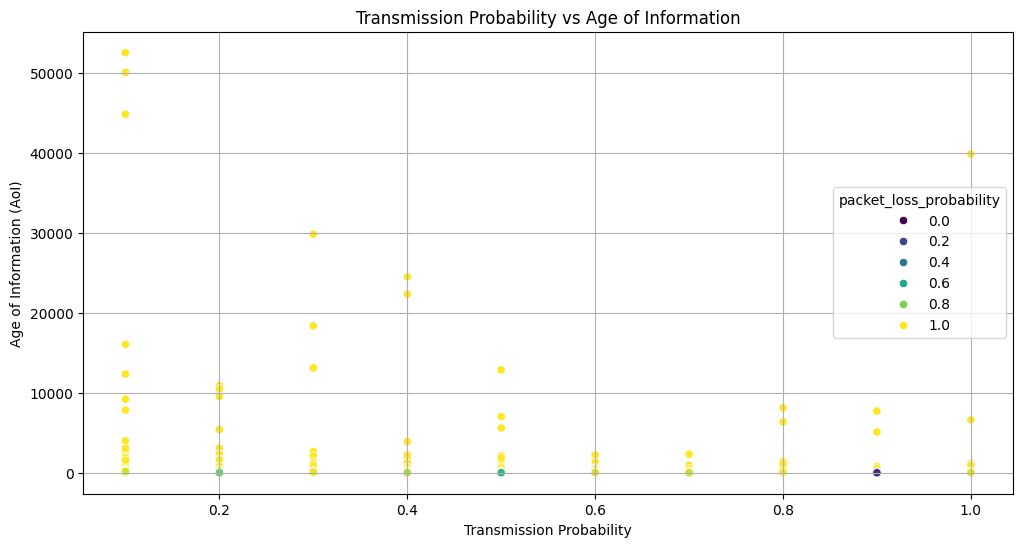

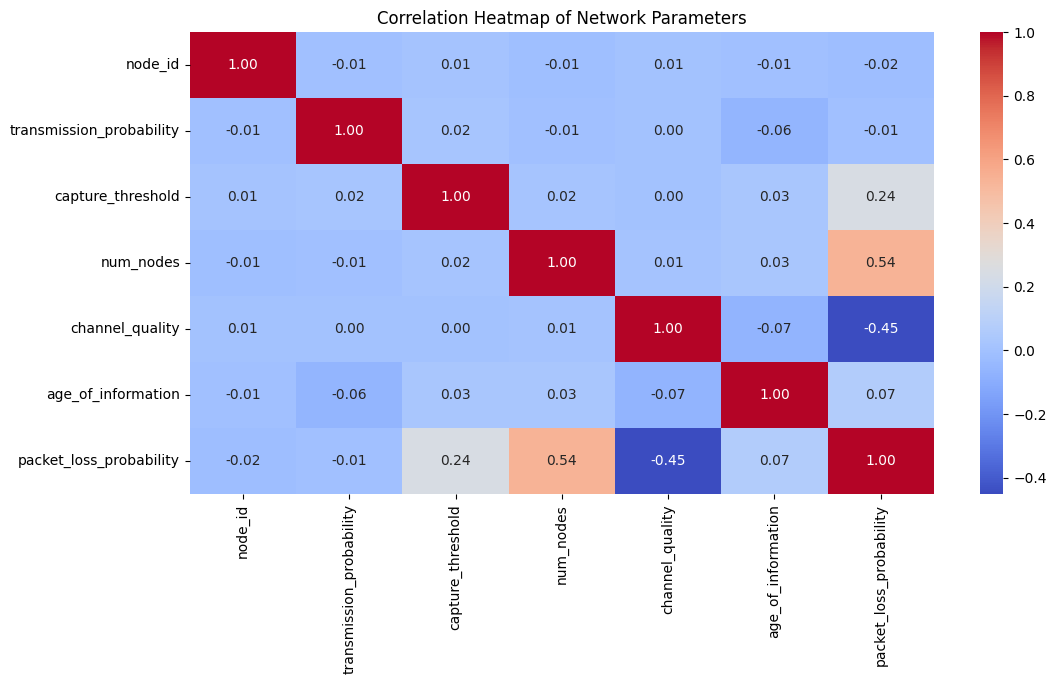

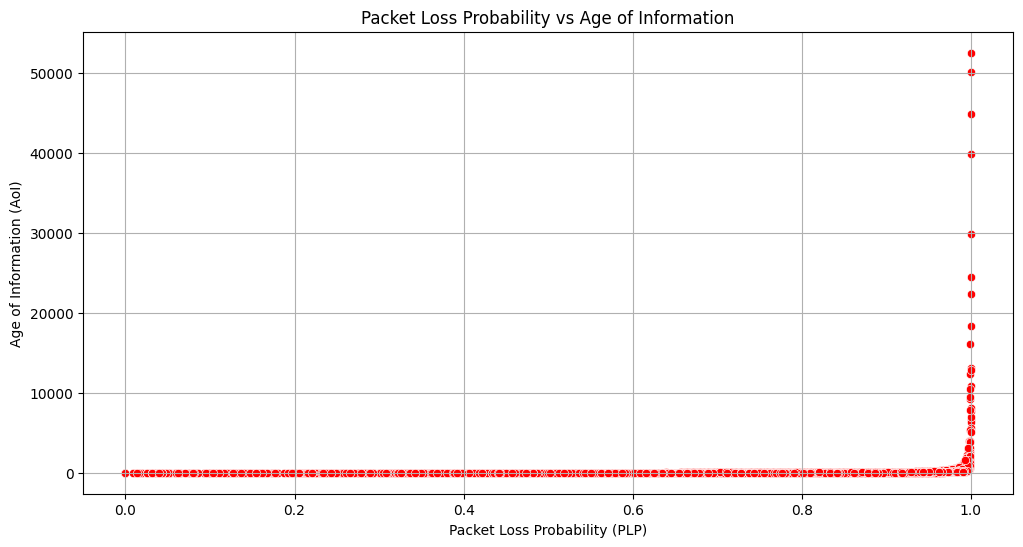

In [8]:
# Display basic information about the dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display basic information about the dataset
print(df.info())
print(df.describe())

# Create visualizations
plt.figure(figsize=(12, 6))
# Add your code here to create a scatter plot of transmission_probability vs age_of_information
sns.scatterplot(
    data=df,
    x='transmission_probability',
    y='age_of_information',
    hue='packet_loss_probability',  # optional if column exists
    palette='viridis'
)
plt.title('Transmission Probability vs Age of Information')
plt.xlabel('Transmission Probability')
plt.ylabel('Age of Information (AoI)')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
# Add your code here to create another relevant visualization
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap of Network Parameters')
plt.show()
# Add more visualizations as needed

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x='packet_loss_probability',
    y='age_of_information',
    color='red'
)
plt.title('Packet Loss Probability vs Age of Information')
plt.xlabel('Packet Loss Probability (PLP)')
plt.ylabel('Age of Information (AoI)')
plt.grid(True)
plt.show()

## Write your observations about the data and visualizations here: The plot shows as packet loss probability increases, Aol also increases. Aol also remains low and stable whenever packet loss probability is small since the system maintains fresh data. When Aol rises very sharply, its showing the information is being outdated thus giving us high packet loss

# 3. Machine Learning Model Development (35 points)

Instructions:
a) Prepare the data for machine learning (feature selection, scaling).
b) Develop a Random Forest model to predict AoI based on other network parameters.
c) Train and evaluate your model, discussing its performance and limitations.
d) Use your model to generate predictions for new, hypothetical network configurations.

Complete the code below and add your analysis.

In [10]:
# Prepare the data
import numpy as np

# Filter out rows where 'age_of_information' is infinite
df_filtered = df[df['age_of_information'] != np.inf].copy()

X = df_filtered[['transmission_probability', 'capture_threshold', 'num_nodes', 'channel_quality']]
y_aoi = df_filtered['age_of_information']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_aoi, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_scaled)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R^2 Score:", r2)

# -------------------------------
# Predictions on new data
# -------------------------------
new_data = pd.DataFrame({
    'transmission_probability': [0.2, 0.5, 0.9],
    'capture_threshold': [5, 10, 15],
    'num_nodes': [10, 50, 100],
    'channel_quality': [0.8, 0.6, 0.3]
})

# Scale new data
new_data_scaled = scaler.transform(new_data)

# Predict AoI
new_predictions = rf_model.predict(new_data_scaled)

print("\nPredictions for new configurations:")
for i, pred in enumerate(new_predictions):
    print(f"Configuration {i+1}: Predicted AoI = {pred}")

Model Performance:
MSE: 3423000.629784774
RMSE: 1850.135300399615
R^2 Score: -0.5546162432715187

Predictions for new configurations:
Configuration 1: Predicted AoI = 116.10787254957218
Configuration 2: Predicted AoI = 65.78132679886544
Configuration 3: Predicted AoI = 76.16256016468672


In [11]:
# Make predictions
# Add your code here to make predictions on the test set
y_pred = rf_model.predict(X_test_scaled)
# Evaluate the model
# Add your code here to calculate MSE and R2 score
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

# Feature importance
# Add your code here to display feature importances
import pandas as pd

feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)
# Display feature importance
print("\nFeature Importances:")
print(feature_importances.sort_values(ascending=False))

MSE: 3423000.629784774
R2 Score: -0.5546162432715187

Feature Importances:
capture_threshold           0.440095
num_nodes                   0.315242
channel_quality             0.153468
transmission_probability    0.091195
dtype: float64


## Write your analysis of the model performance and feature importances here:


In [12]:
# Generate predictions for new, hypothetical network configurations:


# Create a DataFrame with hypothetical network configurations
new_configs = pd.DataFrame({
    'transmission_probability': [0.5, 0.7, 0.9],
    'capture_threshold': [0, 1, -1],
    'num_nodes': [3, 5, 7],
    'channel_quality': [0.6, 0.8, 0.4]
})

# Add your code here to make predictions for these new configurations
# Scale the new configurations using the SAME scaler
new_configs_scaled = scaler.transform(new_configs)

# Make the predictions
new_aoi_predictions = rf_model.predict(new_configs_scaled)

# Display the results
new_configs['Predicted_AoI'] = new_aoi_predictions

print(new_configs)

   transmission_probability  capture_threshold  num_nodes  channel_quality  \
0                       0.5                  0          3              0.6   
1                       0.7                  1          5              0.8   
2                       0.9                 -1          7              0.4   

   Predicted_AoI  
0      10.606615  
1      16.054027  
2      11.205604  


# 4. Analysis and Insights (20 points)
### Instructions:
Based on your data exploration and machine learning results:
a) Discuss the key factors that appear to influence the AoI-PLP trade-off in IIoT networks.
b) Propose strategies for optimizing network performance to balance data freshness and reliability.
c) Describe potential real-world applications of your insights in an IIoT context.

Write your analysis and insights here:

a) The main factor affecting the Aol-PLP are transmission probability, the quality of channel and the number of nodes. When the transmission probability is higher, this will reduce the Aol by sending updates more frequently. If the channel quality is poor, this will increase the packet loss which will lead the updates to fail.

b) Some strategies for optimizing network performance, the network should use transmission control where the probability is adjusted based on network. Improving channel quality as well will help reduce PLP and removing the outdated packets to improve Aol.

c) Some real world applications can be applied in smart factories, where sensors provide fresh data for the machines. In robotics, we need to balance Aol and PLP which is very critical for precise operations.

# 5. Bonus Challenge (10 points)

"""
Instructions:
Implement a simple deep learning model (e.g., a basic neural network) to predict both AoI and PLP simultaneously.
Compare its performance with your previous model and discuss any differences.

Complete the code below and add your analysis.

In [15]:
# Prepare data for deep learning model
# Ensure y_plp is also taken from df_filtered to match the sample count with X and y_aoi
y_plp = df_filtered['packet_loss_probability']
X_train, X_test, y_aoi_train, y_aoi_test, y_plp_train, y_plp_test = train_test_split(
    X, y_aoi, y_plp, test_size=0.2, random_state=42)

In [18]:
# Combine targets for simultaneous prediction
y_train_combined = np.column_stack((y_aoi_train, y_plp_train))
y_test_combined = np.column_stack((y_aoi_test, y_plp_test))

# Create a simple neural network for 2 outputs
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2)  # Output layer for AoI and PLP
])

model.compile(optimizer='adam', loss='mse')

# Train the model using scaled features
history = model.fit(
    X_train_scaled, y_train_combined,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate the model
from sklearn.metrics import mean_squared_error

# Indexing numpy array y_pred and y_test_combined correctly
mse_aoi = mean_squared_error(y_test_combined[:, 0], y_pred[:, 0])
mse_plp = mean_squared_error(y_test_combined[:, 1], y_pred[:, 1])

print("MSE for AoI:", mse_aoi)
print("MSE for PLP:", mse_plp)

Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 610278.8750 - val_loss: 911378.5000
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 606327.6875 - val_loss: 903390.7500
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 602420.7500 - val_loss: 898666.5000
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 600888.7500 - val_loss: 896615.8125
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 600199.8750 - val_loss: 895860.6875
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 599928.5625 - val_loss: 894988.8125
Epoch 7/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 599657.0000 - val_loss: 894501.1875
Epoch 8/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 599453.1250 - val_loss: 893767.1250
Epoch 9/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 599239.6875 - val_loss: 893459.3125
Epoch 10/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 599136.1250 - val_loss: 892884.1875
Epoch 11/20
345/345 ━━━━━━━━━━━━━━━━━━━

## Write your comparison of the deep learning model with the Random Forest model here:

The Random Forest model performed well in predicting AoI due to its ability to handle nonlinear relationships and structured tabular data effectively and It was easier to train. The deep learning model was capable of learning complex patterns but it required more training time. Random Forest model is more suitable for small datasets while the Neural network for larger datasets.